In [ ]:
# import h5py
import pickle
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import math
import fittings

#open h5 flux files
# filename = 'Tiberius_normalized_specphot.h5'
# with h5py.File(filename, 'r') as f:
#     print("Keys: %s" % f.keys())
#     flux_key = list(f.keys())[0]
#     print(flux_key)
#     fluxes = f[flux_key][()]
#     print(fluxes.shape)

#open pickled time_frame
time_frame = pickle.load(open("time.pickle","rb"))
wb_fluxes = pickle.load(open("wb_fluxes.pickle","rb"))
time_frame = time_frame - int(time_frame[0])
WL_flux = pickle.load(open('WL_flux.pickle', 'rb'))

wl, width, u1, u2 = np.loadtxt('LD_coefficients.dat', unpack=True, usecols=(0,1,2,4))

g = [0.1437859369, 0.1, 0.1]
wb_fluxes.shape

In [ ]:

ipopts = []
epopts = []
iErr = []
eErr = []
snrs =[]
phases=[]
for n, fluxes in enumerate(wb_fluxes):
    #get rid of nans first
    ind = []
    for j, flux in enumerate(fluxes):
        if math.isnan(flux):
            ind.append(j)
    time_frame_nonan = np.delete(time_frame, ind)
    fluxes_nonan = np.delete(fluxes, ind)
    
    #fittings and plot on full lightcurve
    fittings.set_u([u1[n], u2[n]])
    poptLin, not_used = fittings.plot_fit(fittings.bat_lin, time_frame_nonan, fluxes_nonan, g, plot=False) 
    m = poptLin[1]
    c = poptLin[2]
    rp_guess = poptLin[0]

    def temp(t, rp):
        lin = (t * m) + c
        return fittings.bat(t, rp) / lin

    #fittings and plot on cut light curves
    i, e = fittings.plot_cut_fit(temp, fluxes_nonan, time_frame_nonan, -0.06733668341708543, 0.06733668341708543, rp_guess, split= True, plot = True)
    ipopts.append(i[0][0])     
    epopts.append (e[0][0])
    iErr.append(np.sqrt(i[1][0][0]))
    eErr.append(np.sqrt(e[1][0][0]))
    print(ipopts[n], iErr[n], epopts[n], eErr[n])
     
    # find phase range that only probes egress and ingress
    snr, phases, iUnc, eUnc = fittings.snr_plot(temp, fluxes_nonan, time_frame_nonan, 100, 0.16, plot=False) 
    snrs.append(snr)

    plt.figure()
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["font.size"] = 13
    plt.plot(phases, iUnc,'x', label = 'ingress')
    plt.plot(phases, eUnc,'x', label = 'egress')
    plt.ylabel('Relative uncertainty in transit depth')
    plt.xlabel('Phases probed')
    plt.legend()
    plt.savefig('errorTD.pdf')
    plt.show()


    # print(fittings.bat_test(time_frame_nonan, 0.1437859369, -0.075, 0.075))

In [ ]:
for n, i in enumerate(snrs):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["font.size"] = 13
    plt.plot(phases, i, 'x', label = f'Wavelength (μm) = {wl[n]}', markersize = 4)
    plt.xlabel('Phases probed')
    plt.ylabel('SNR')
    plt.legend()
    plt.savefig('compareSNR.pdf')

In [ ]:
#mean snrs plot across all wavelength
plt.figure()
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 13
plt.plot(phases,np.mean(snrs, axis=0), 'x', markersize = 5) 
plt.xlabel('Phases probed')
plt.ylabel('Mean SNR across all wavelengths') 
plt.legend()
plt.savefig('MeanSNR.pdf')
plt.show()   

snrsMax = []
phasesMax = []
for snr in snrs:
    ind = np.argmax(snr)
    phasesMax.append(phases[ind])

plt.plot(wl, phasesMax,'x')


In [ ]:

iTD = [i * i for i in ipopts]
iTDerr = [(2 *(a / b)) * c for a, b, c in zip(iErr, ipopts, iTD)]

eTD = [i * i for i in epopts]
eTDerr = [(2 *(a / b)) * c for a, b, c in zip(eErr, epopts, eTD)]
print(eTDerr)
plt.figure().set_figwidth(15)
plt.errorbar(wl, iTD, yerr = iTDerr, xerr = 0, fmt = 'x', markersize = 4, label = 'ingress', elinewidth=0.8)
plt.errorbar(wl, eTD, yerr = eTDerr , xerr = 0, fmt = 'x', markersize = 4, label = 'egress', elinewidth=0.8)
plt.ylim(0.0195, 0.0245)
# plt.xlim(0,3.5)
plt.ylabel('Transit depth')
plt.xlabel('Wavelength (μm)')
plt.legend()
plt.savefig('Spectrum.pdf')
plt.show()


/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


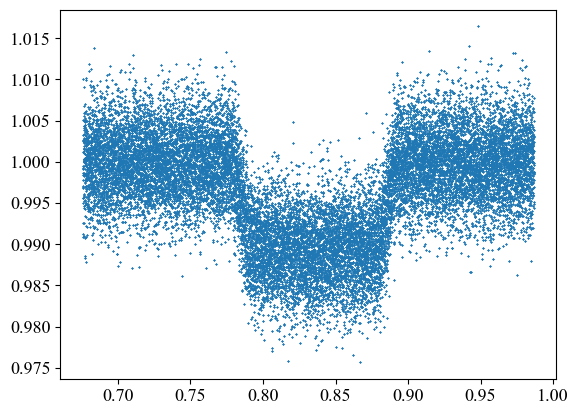

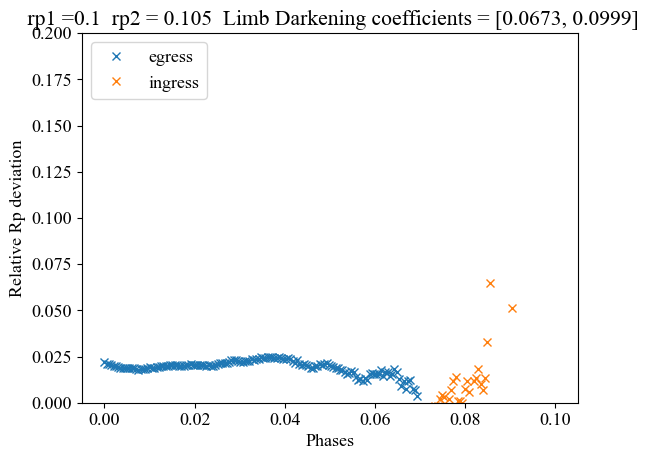

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


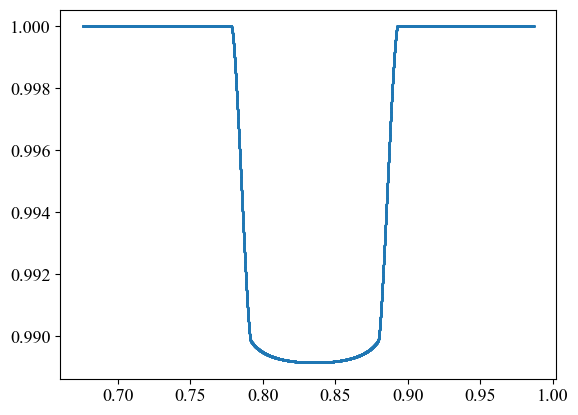

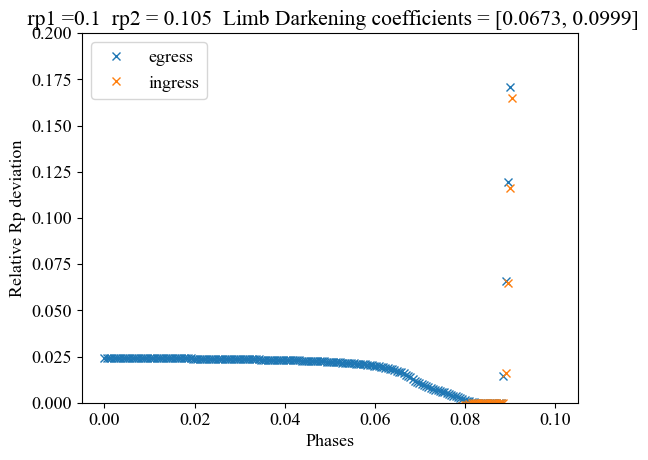

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


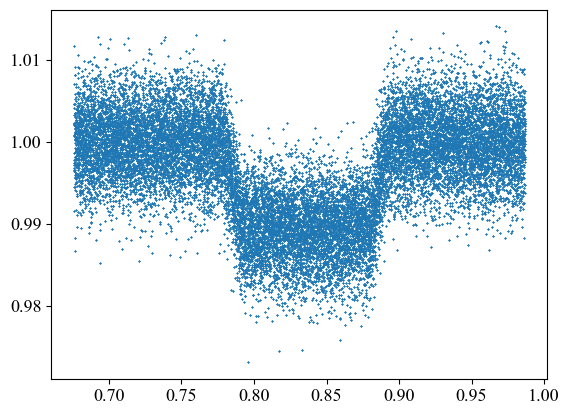

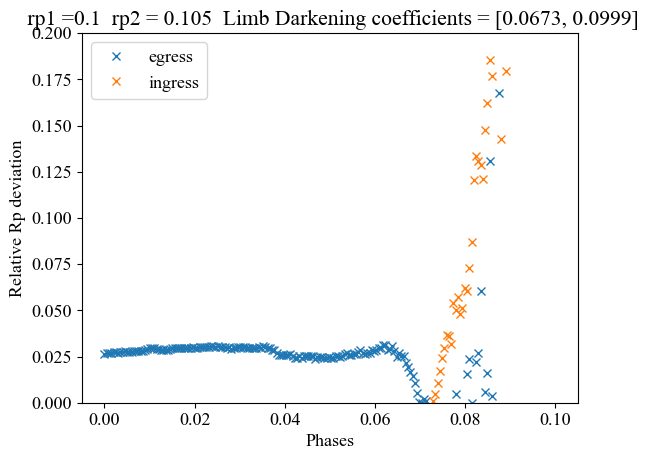

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


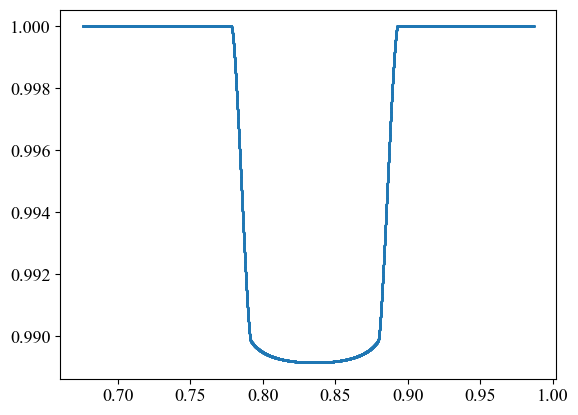

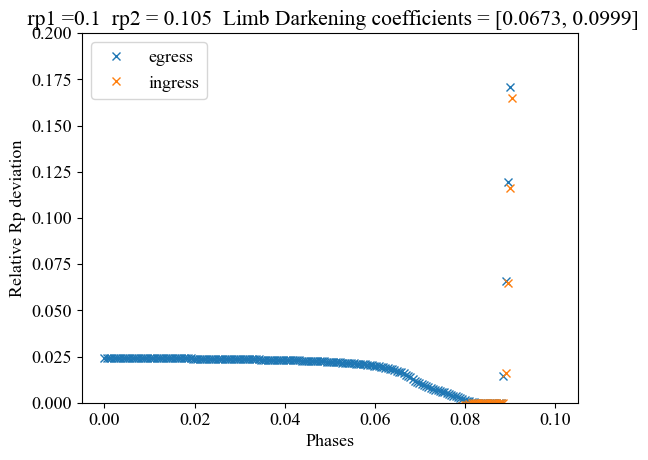

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


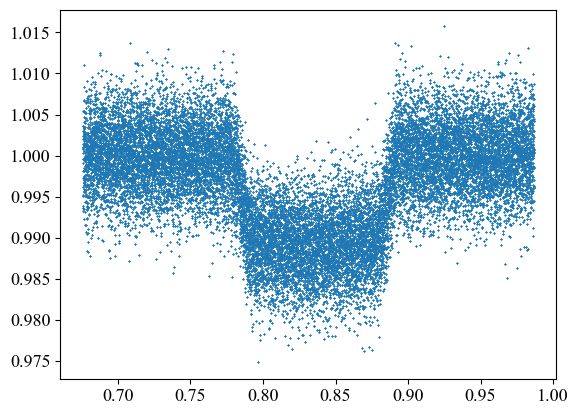

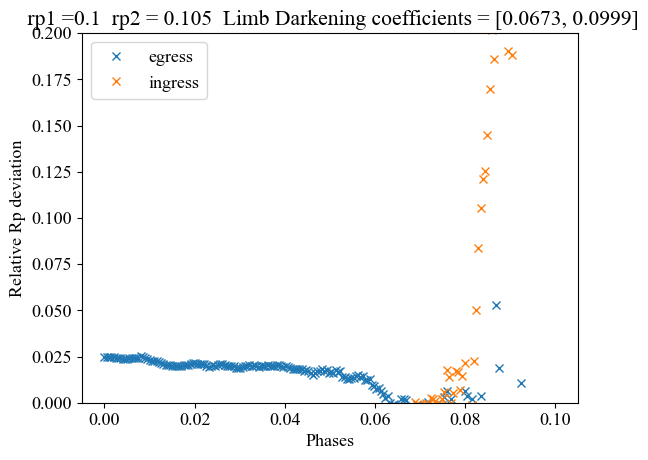

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


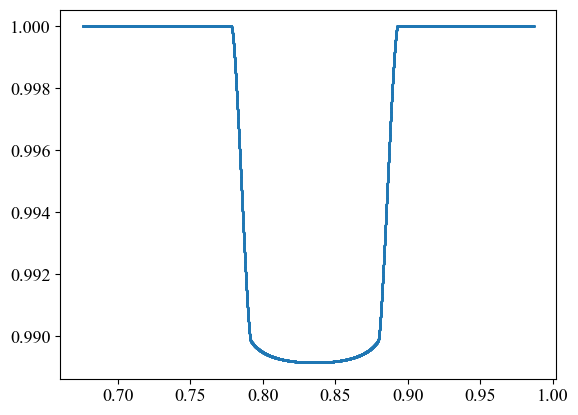

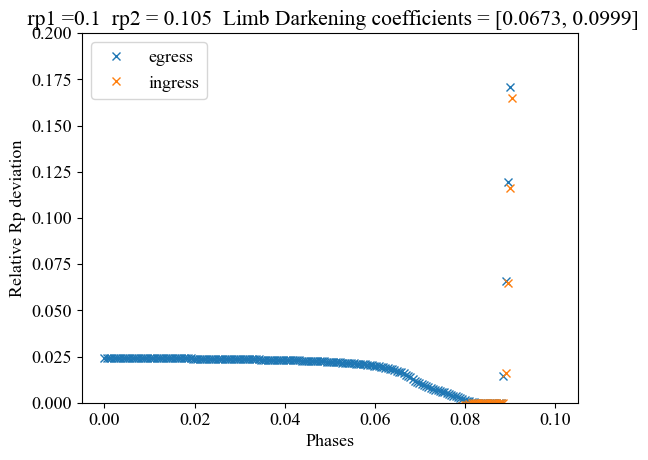

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


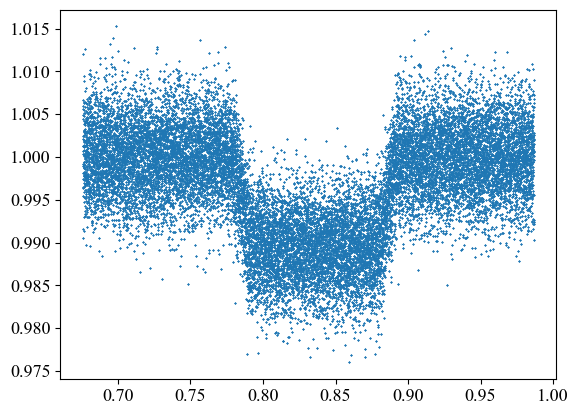

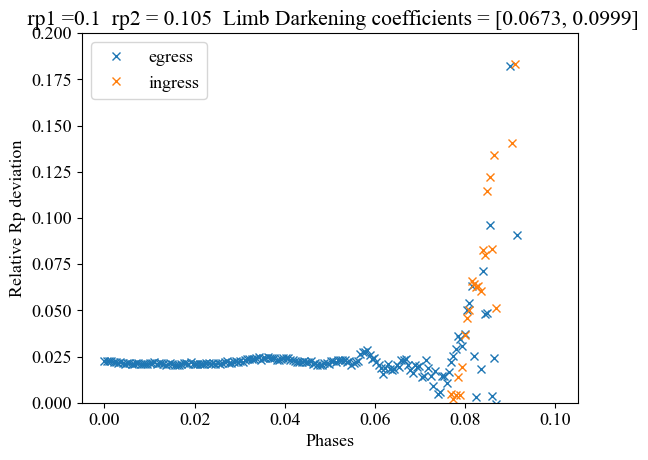

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


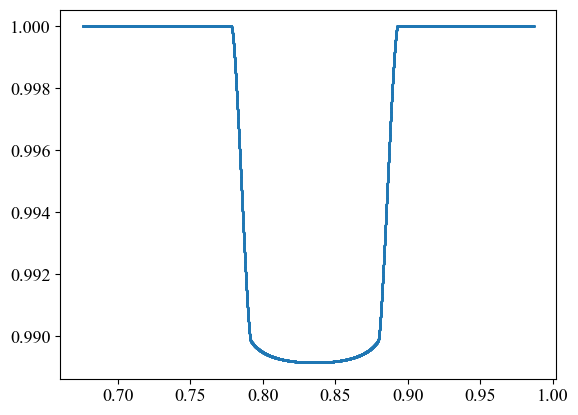

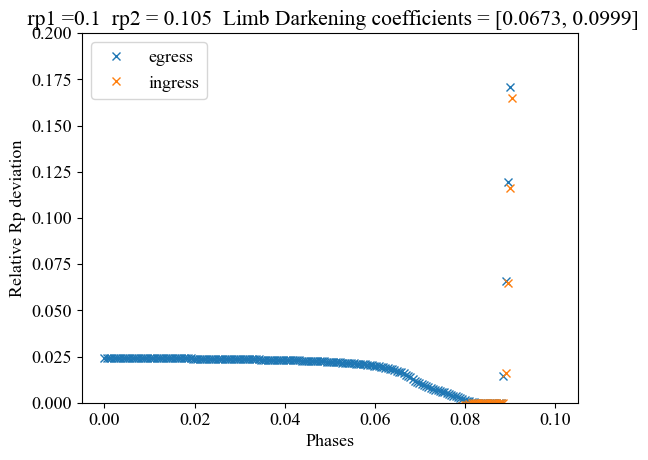

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


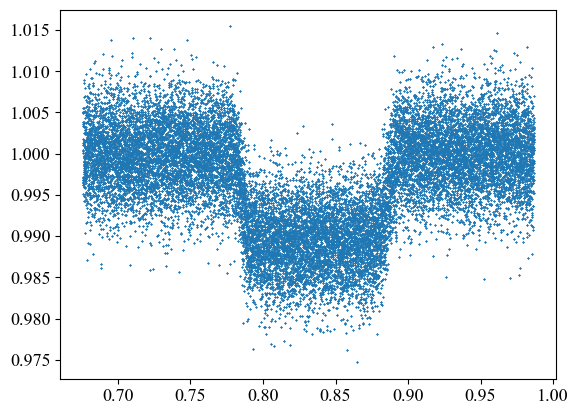

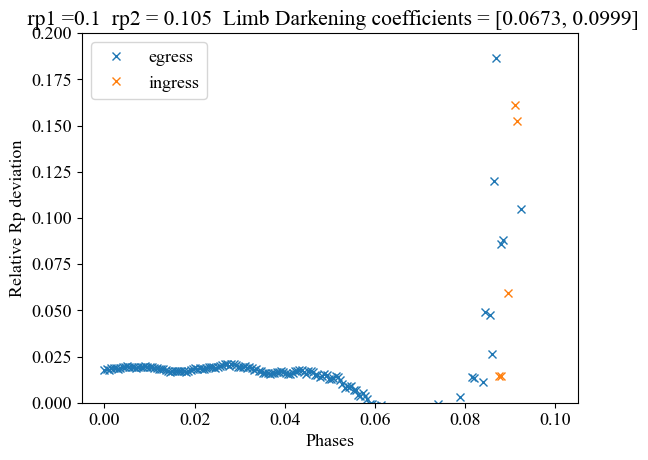

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


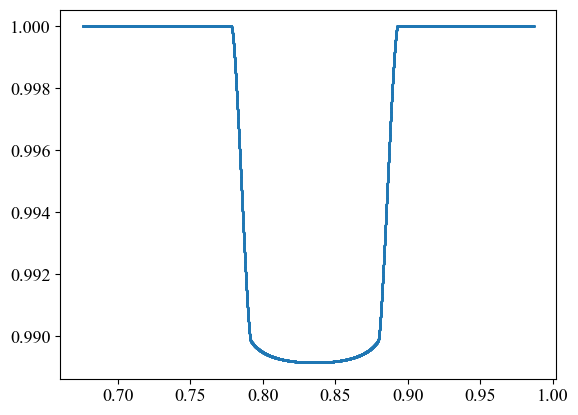

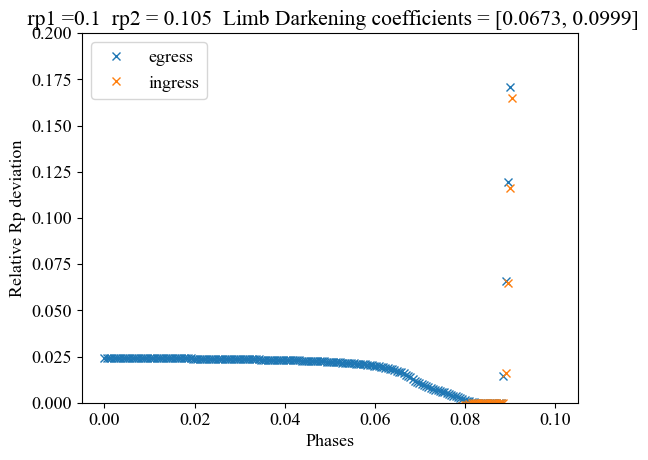

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


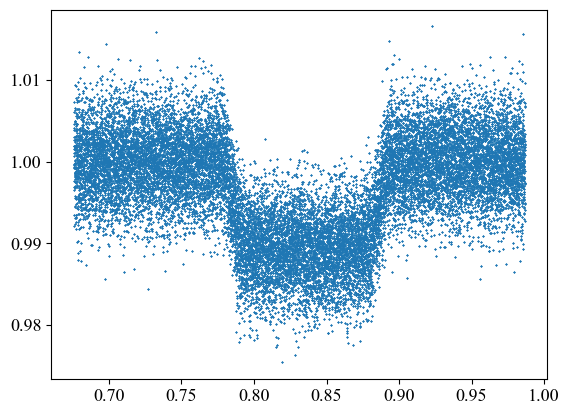

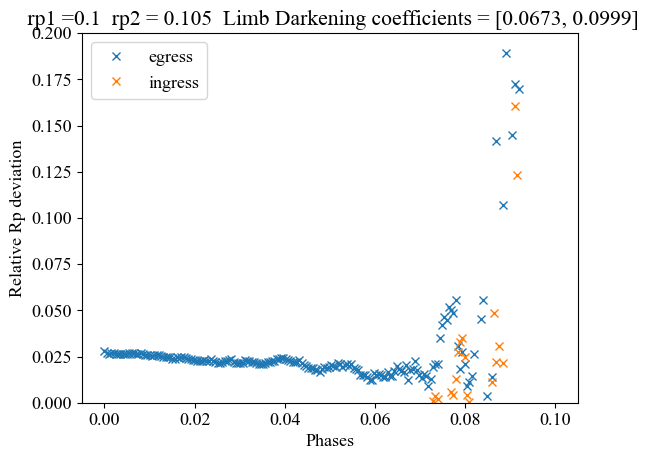

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


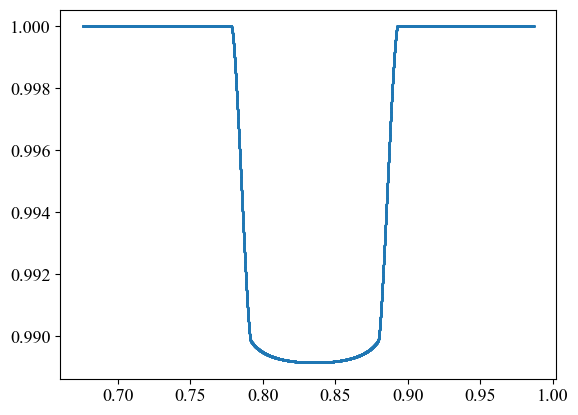

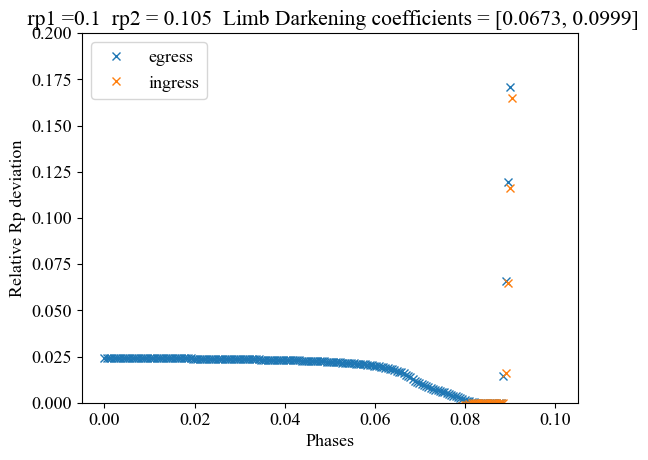

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


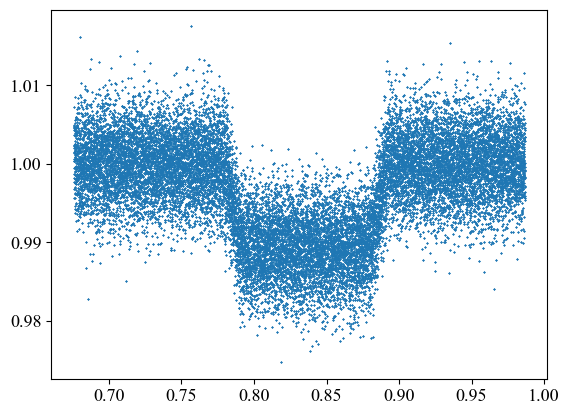

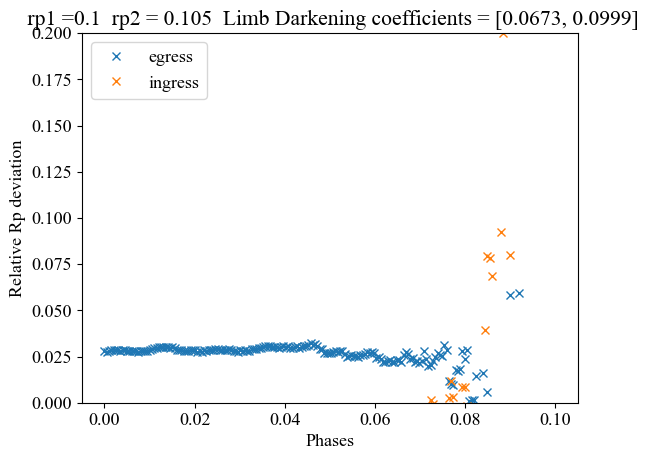

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


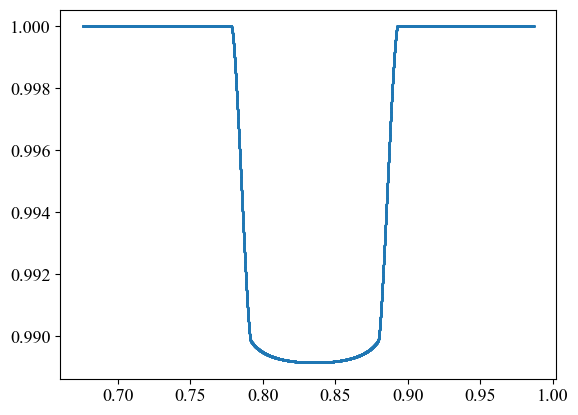

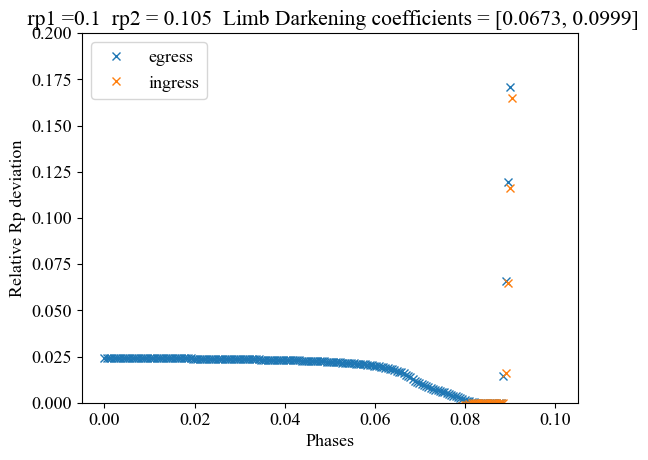

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


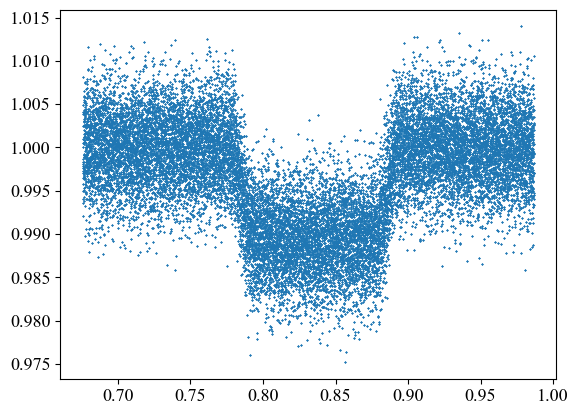

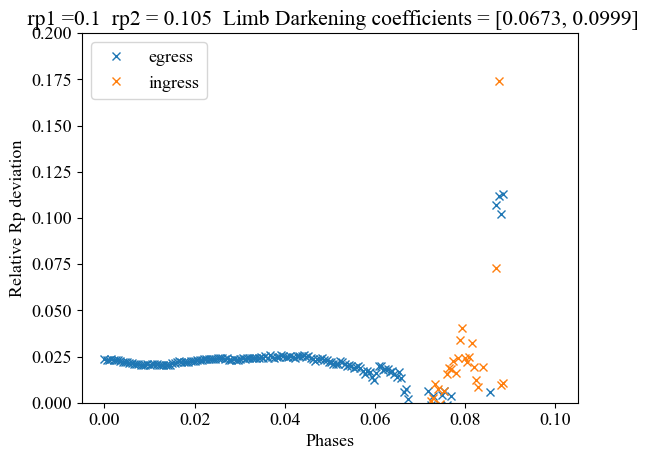

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


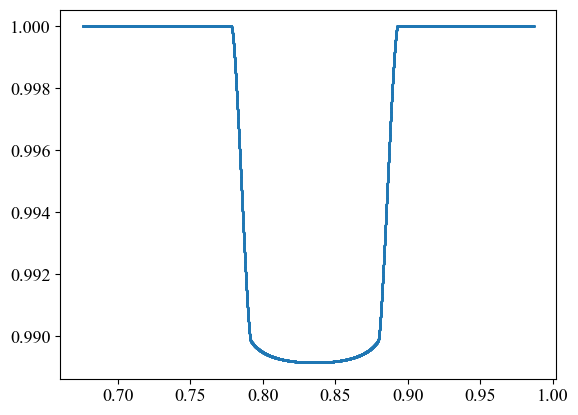

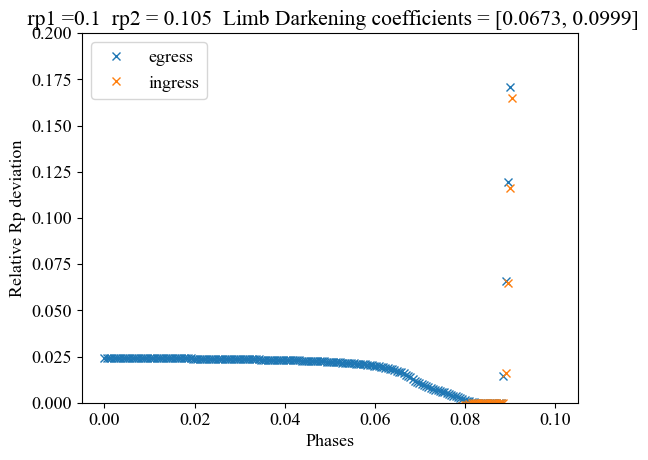

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


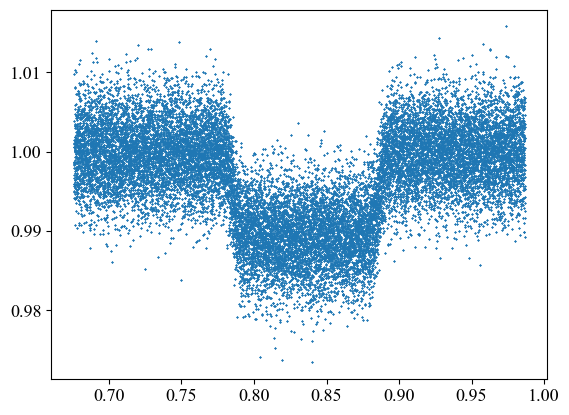

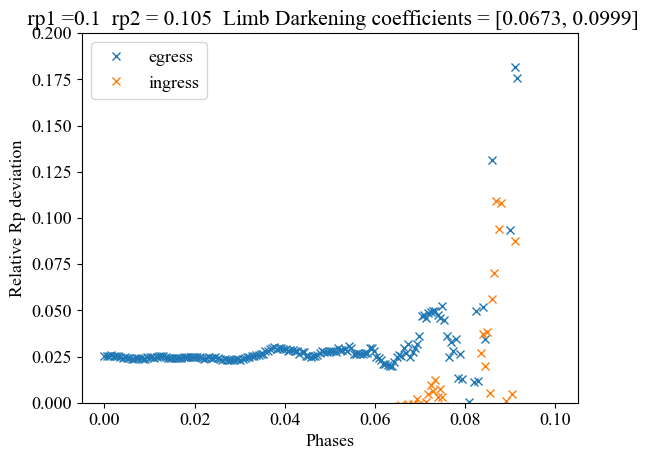

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


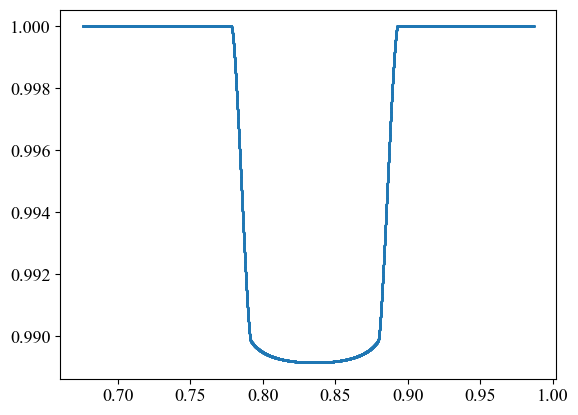

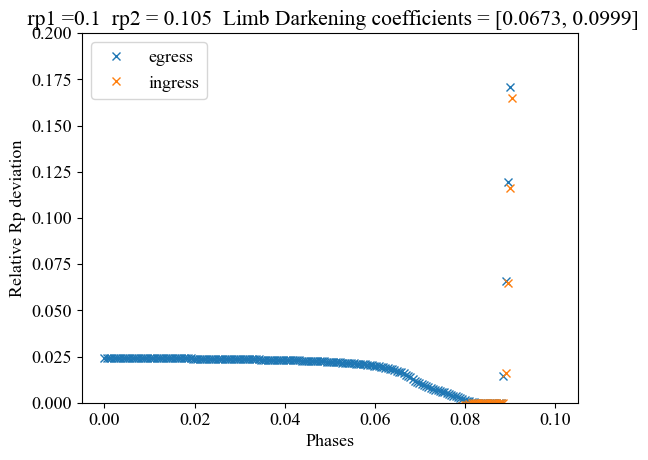

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


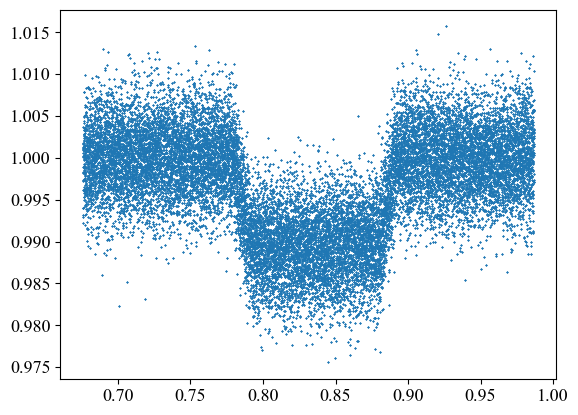

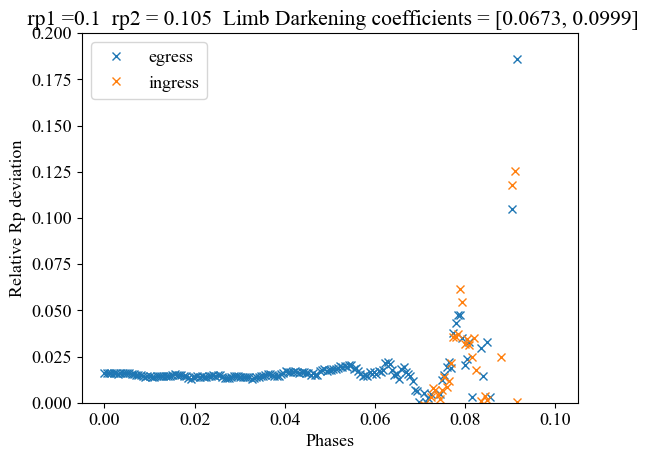

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


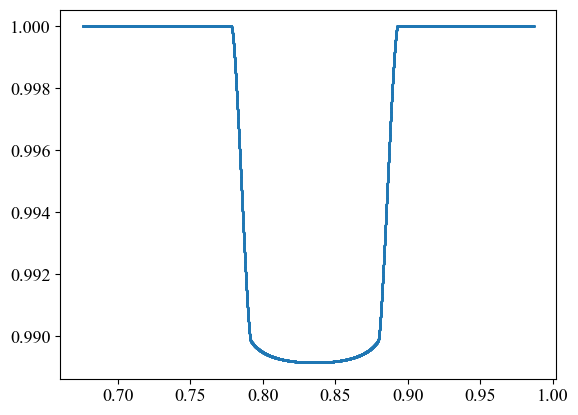

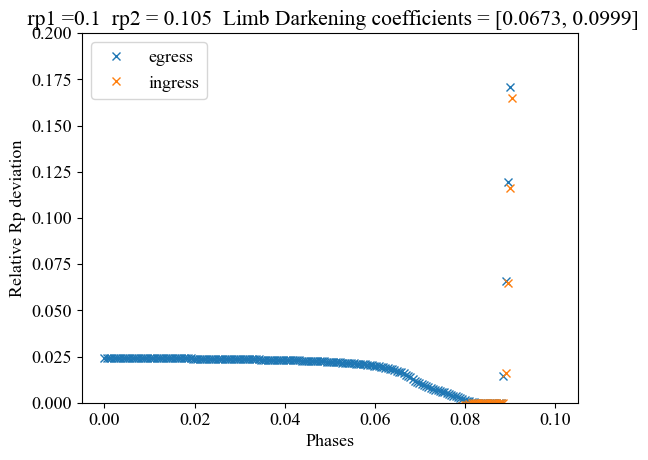

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


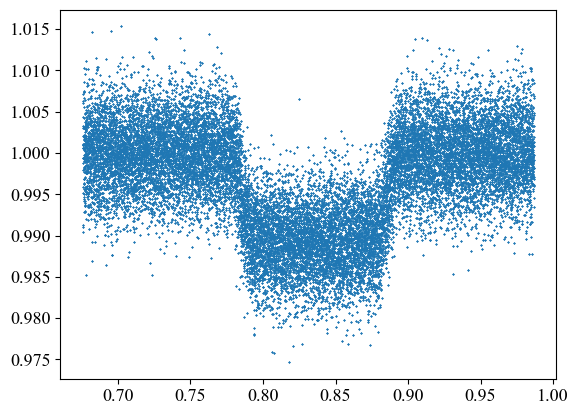

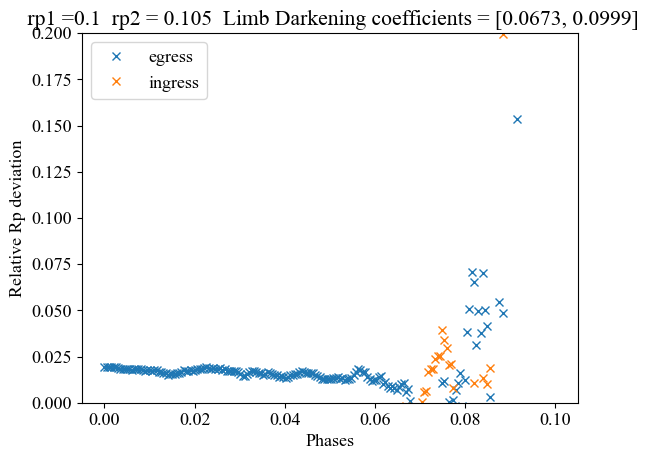

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


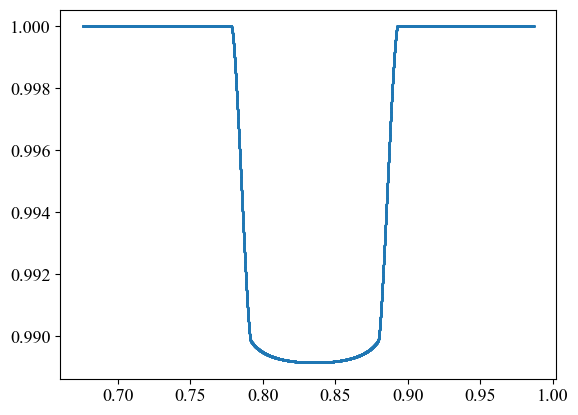

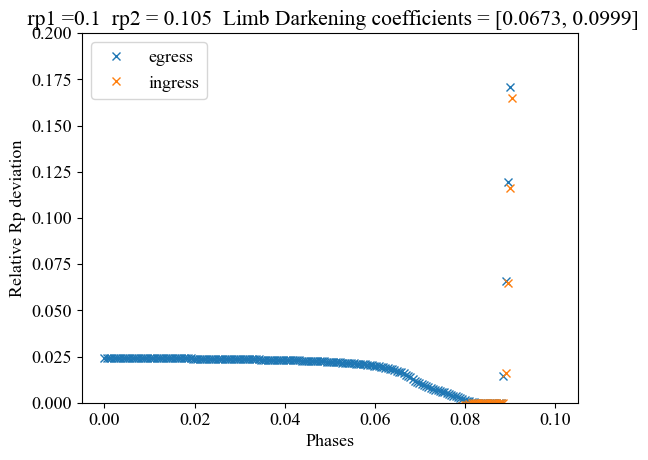

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


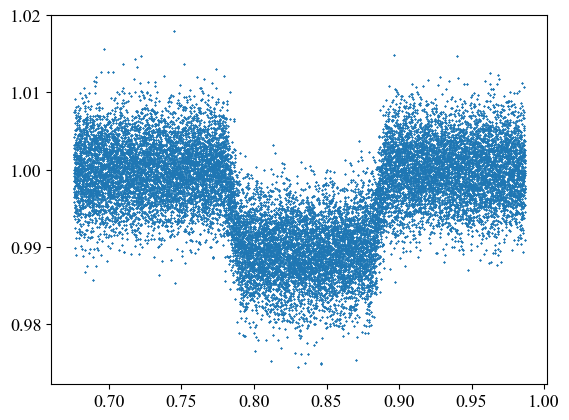

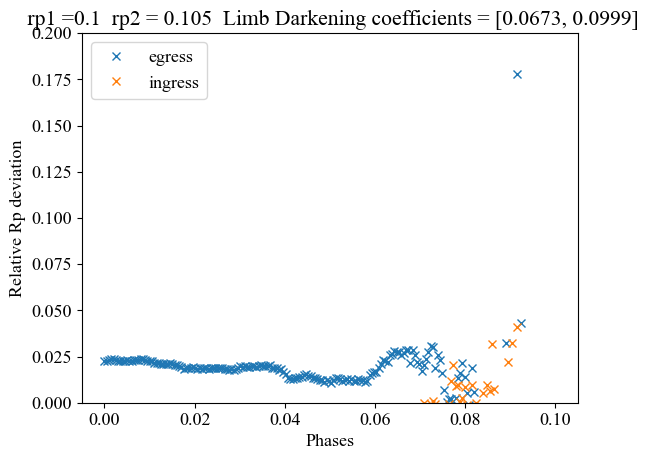

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


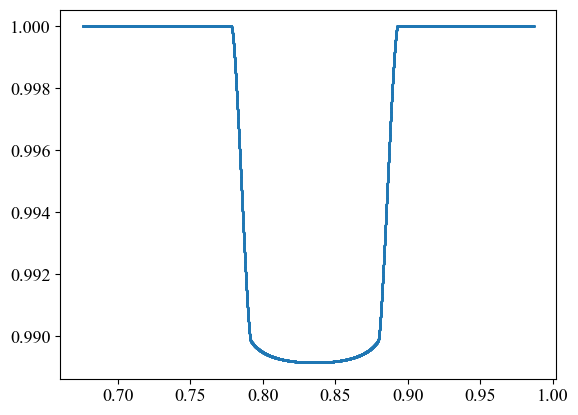

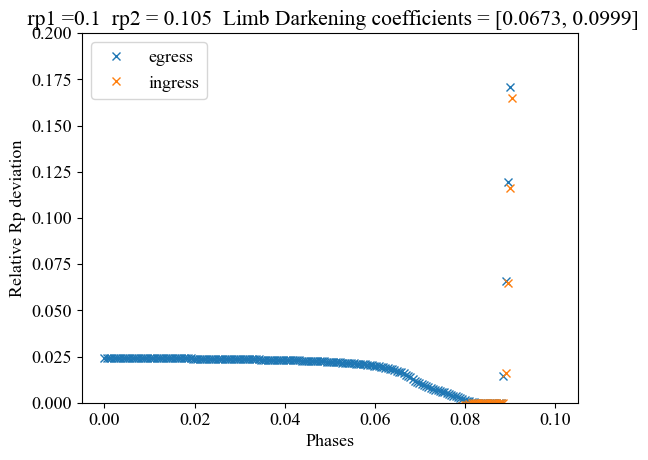

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


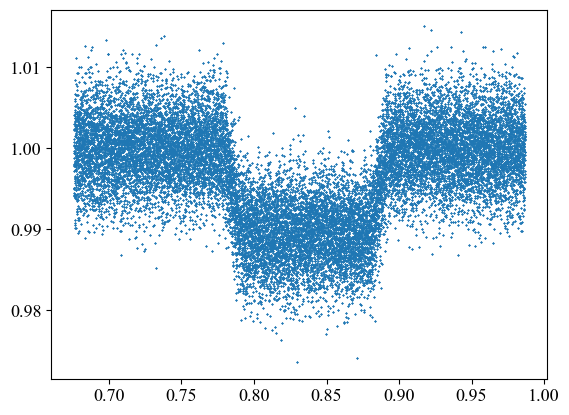

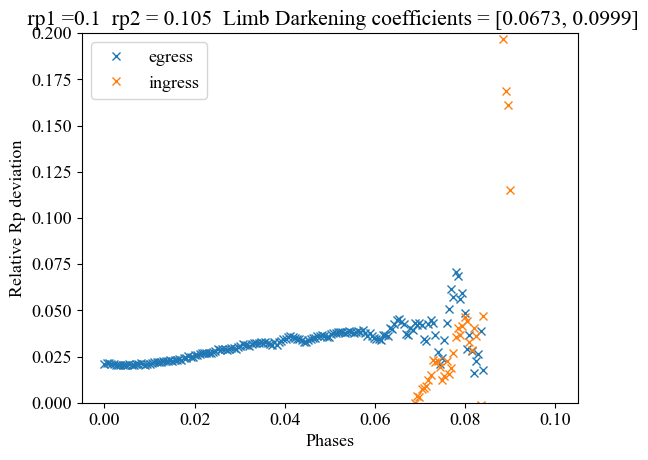

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


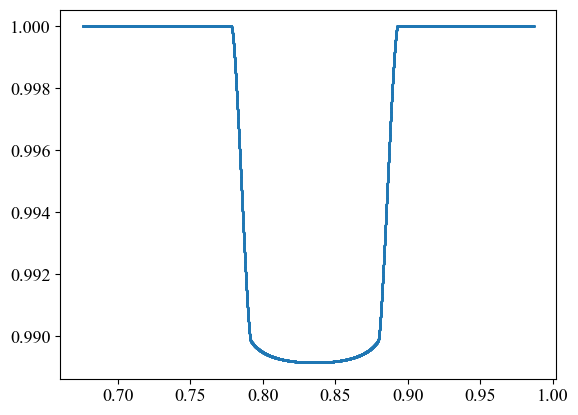

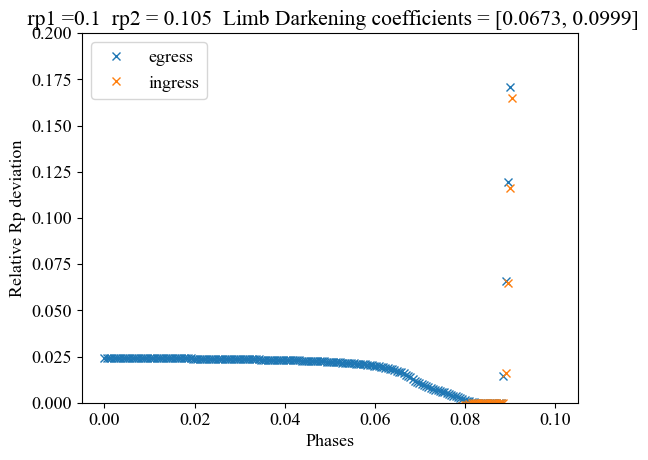

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


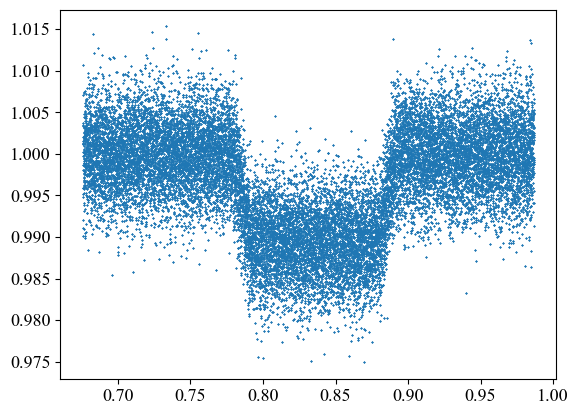

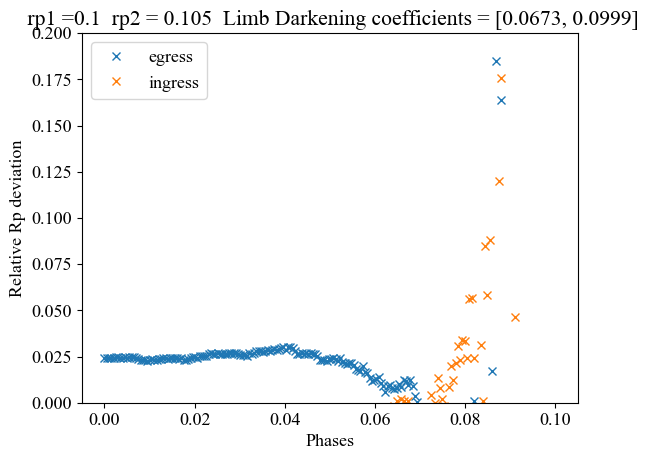

/Users/sanskarlimbu/Documents/Imperial College/Year 2/urop/wb_fluxes_fit/fittings.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, times, fluxes, p0 = guesses)


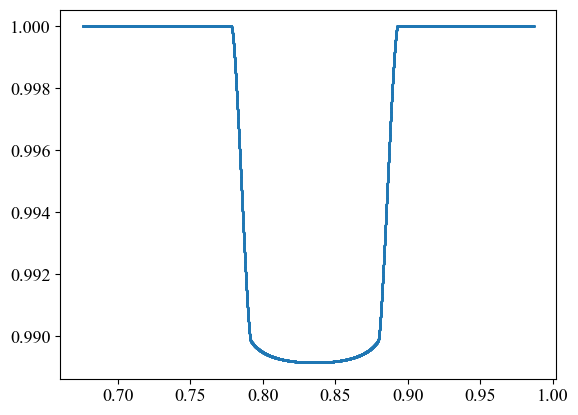

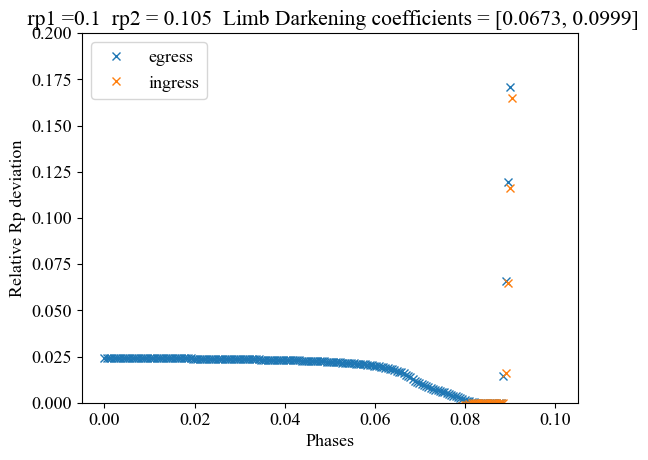

KeyboardInterrupt: 

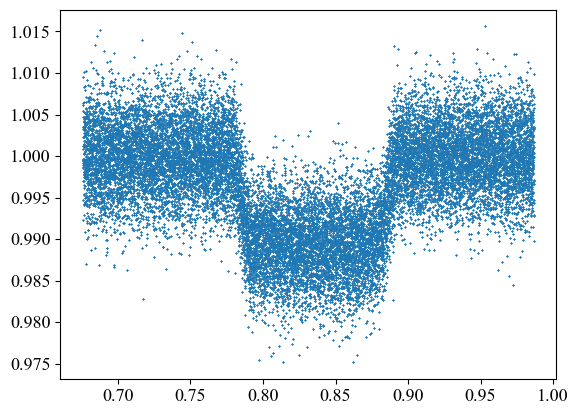

In [12]:
#DATA ANALYSIS OF SIMULATION
phases = []
ing = []
eg = []
ing_perf = []
eg_perf = []
samp = 200
n=len(u1) -1
for i in range(n):
    fittings.set_u([u1[n],u2[n]])
    p, d1,d2= fittings.cat_cut_fit(time_frame, 0.1, 0.105, 0.004, -0.0, 0.0, [0.0, 0.1], sample=samp, repeat=True)
    phases.append(p)
    ing.append(d1)
    eg.append(d2)
    p, d1,d2= fittings.cat_cut_fit(time_frame, 0.1, 0.105, 0.00, -0.0, 0.0, [0.0, 0.1], sample=samp, repeat=True)
    ing_perf.append(d1)
    eg_perf.append(d2)
    

ing_tot = np.zeros(samp)
eg_tot = np.zeros(samp)
ing_perf_tot = np.zeros(samp)
eg_perf_tot = np.zeros(samp)
for i in range(n):
    ing_tot = ing_tot + ing[i]
    eg_tot = eg_tot + eg[i]
    ing_perf_tot = ing_perf_tot + ing_perf[i]
    eg_perf_tot = eg_perf_tot + eg_perf[i]

ing_mean = [t / n for t in ing_tot]
eg_mean = [t / n for t in eg_tot]
ing_perf_mean = [t / n for t in ing_perf_tot]
eg_perf_mean = [t / n for t in eg_perf_tot]
# plt.plot(phases[0], ing_mean, 'x')
# plt.ylim(0,0.1)
# plt.show()
# plt.plot(phases[0], eg_mean, 'x')
# plt.ylim(0,0.1)


In [ ]:
len(ing_mean)

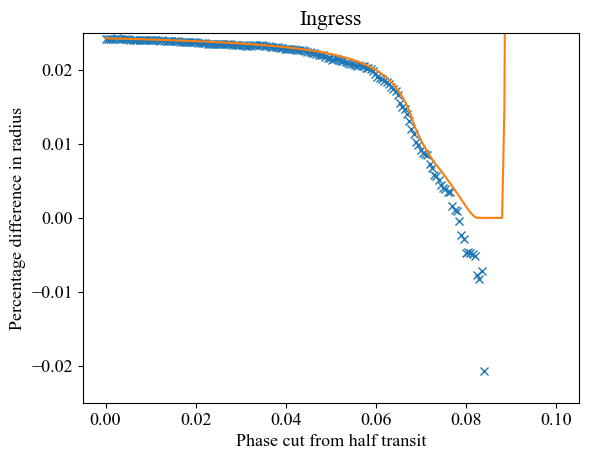

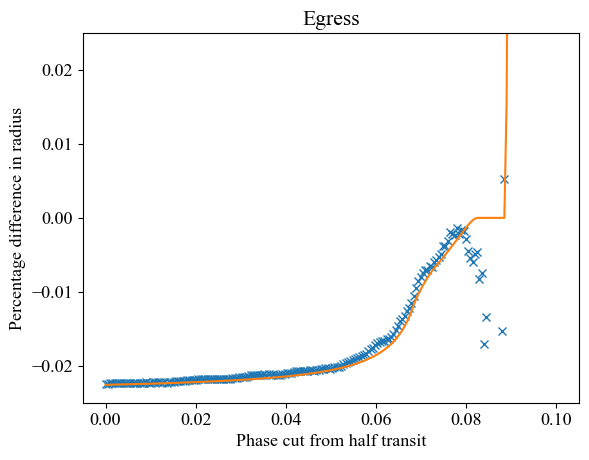

In [11]:
plt.plot(phases[0], ing_mean, 'x')
plt.plot(phases[0], ing_perf_mean)
plt.ylim(-0.025,0.025)
plt.title('Ingress')
plt.xlabel('Phase cut from half transit')
plt.ylabel('Percentage difference in radius')
plt.show()

plt.plot(phases[0], eg_mean, 'x')
plt.plot(phases[0], eg_perf_mean)
plt.ylim(-0.025,0.025)
plt.title('Egress')
plt.xlabel('Phase cut from half transit')
plt.ylabel('Percentage difference in radius')
plt.show()

# testind = []
# test = np.array(dev_mean1)
# for n, i in enumerate(test):
#     if i < 0.0001:
#         print(n)
#         break


In [ ]:
lol= np.loadtxt('plot.txt', unpack=True)
lol = lol.transpose()
plt.plot(lol[0], lol[1]/max(lol[1]), 'black', label='morning')
plt.plot(lol[0], lol[2]/max(lol[2]), 'red', ls = '--', label='evening')

n1 = []
n2 = []
for n, i in enumerate(zip(lol[1], lol[2])):
    if i[0] >0:
        n1.append(n)
    if i[1]>0:
        n2.append(n)

print(lol[0][min(n1)] - lol[0][min(n2)] )
print(lol[0][max(n1)] - lol[0][max(n2)])

In [ ]:
ind = []
ingress =[]
egress =[]
snr = []
for j, flux in enumerate(WL_flux):
    if math.isnan(flux):
        ind.append(j)
time_frame_nonan = np.delete(time_frame, ind)
fluxes_nonan = np.delete(WL_flux, ind)

#fittings and plot
fittings.set_u([0, 0])
poptLin, not_used = fittings.plot_fit(fittings.bat_lin, time_frame_nonan, fluxes_nonan, g, plot=True) 
m = poptLin[1]
c = poptLin[2]

def temp(t, rp):
    lin = (t * m) + c
    return fittings.bat(t, rp) / lin

